# Use NWM topology to analyze gage pairs
This notebook was adapted from original work by James Halgren (GitHub @jameshalgren).

This notebook demonstrates accessing the National Water Model (NWM) topological definition of the NWM channel routing simulation. Using these topological relationships, we can find all possible connected pairs of reaches with gages in the USGS CONUS river network and analyze data about the paths between gages.

- RouteLink_CONUS.nc sourced from https://www.nco.ncep.noaa.gov/pmb/codes/nwprod/nwm.v3.0.17/parm/domain/RouteLink_CONUS.nc. (note: the version number is not static and gets updated frequently (v3.0.xx))

Install the requirements by using:  
pip install -r requirements.txt  

Note: the source for RouteLink may change as the NWM gets updated by NOAA-OWP. Previous versions are not available for download.

Adapted by Nolan Parker (GitHub @nolanjparker)

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [4]:
routelink_ds = xr.open_dataset("RouteLink_CONUS.nc")

In [5]:
# Subset the dataset to only the columns we want

subslice = [
    "link",
    "to",
    "gages",
    "Length",
    "NHDWaterbodyComID",
]

routelink_df = routelink_ds[subslice].to_dataframe().astype({"link": int, "to": int, "Length": float, "NHDWaterbodyComID": int,})

## Create a topology
With the downloaded Route_Link, we can generate the topology of the CONUS river network

In [6]:
routelink_df = routelink_df.set_index("link")
routelink_df

,to,gages,Length,NHDWaterbodyComID,lon,lat
link,,,,,,
6635572,6635570,b' ',1070.0,-9999,-96.540199,46.228783
6635590,6635600,b' ',1117.0,-9999,-96.530647,46.213486
6635598,6635636,b' ',2303.0,-9999,-96.505341,46.201508
6635622,6635620,b' ',1119.0,-9999,-96.615021,46.200523
6635626,6635624,b' ',3171.0,-9999,-96.637161,46.195522
...,...,...,...,...,...,...
15456832,25371895,b' ',2208.0,-9999,-74.654648,44.979626
25371895,0,b' ',1712.0,-9999,-74.648621,44.996113
15448486,0,b' ',945.0,-9999,-74.504646,44.994370


In [7]:
def replace_downstreams(data, downstream_col, terminal_code):
    '''If a node is above a terminal node, set the downstream id to the negative of the current node.'''
    ds0_mask = data[downstream_col] == terminal_code
    new_data = data.copy()
    new_data.loc[ds0_mask, downstream_col] = ds0_mask.index[ds0_mask]

    # Also set negative any nodes in downstream col not in data.index
    new_data.loc[~data[downstream_col].isin(data.index), downstream_col] *= -1
    return new_data

def extract_connections(rows, target_col, terminal_codes=None):
    '''
    This function was sourced from the NOAA-OWP t-route codebase
    https://github.com/NOAA-OWP/t-route
    Extract connection network from dataframe.

    Arguments:
    ----------
    rows (DataFrame): Dataframe indexed by key_col.
    key_col    (str): Source of each edge
    target_col (str): Target of edge

    Returns:
    --------
    network (dict, int: [int]): {segment id: [list of downstream adjacent segment ids]}
    
    '''
    if terminal_codes is not None:
        terminal_codes = set(terminal_codes)
    else:
        terminal_codes = {0}

    network = {}
    for src, dst in rows[target_col].items():
        if src not in network:
            network[src] = []

        if dst not in terminal_codes:
            network[src].append(dst)
    return network

In [8]:
# Reorganize RouteLink file
routelink_df = routelink_df.sort_index()
routelink_df = replace_downstreams(routelink_df, "to", 0)

In [9]:
# Extract topology from RouteLink file
connections = extract_connections(routelink_df, "to")

## Analyze all connected pairs of gages
We can use routelink_df to find all pairs of reaches with gages in the CONUS river network that are connected by a downstream path. We can then store additional information about each pair, including the length of the path, the number of reaches in the path, and any water bodies on the path.

In [10]:
# Convert the gagestr column of routelink_df into strings
gagestr = []
for i in range(len(routelink_df)):
    gagestr.append(str(routelink_df['gages'].iloc[i]))
routelink_df['gagestr'] = gagestr
routelink_df.head()

,to,gages,Length,NHDWaterbodyComID,lon,lat,gagestr
link,,,,,,,
101,1078719,b' ',3251.0,-9999,-94.640541,31.086876,b' '
179,181,b' ',2412.0,-9999,-67.986412,46.022163,b' '
181,1435,b' ',442.0,-9999,-67.998726,46.016491,b' '
183,185,b' ',112.0,-9999,-67.998833,46.020847,b' '
185,1065,b' ',170.0,-9999,-67.998619,46.019711,b' '


In [11]:
# First link in routelink_df does not have a gage, so we can store its gagestr value as the null value for gages
null_value = routelink_df.iloc[0]["gagestr"]

In [12]:
# Add all links that have a gagestr value other than the null value to gages_string_list
gages_string_list = []
for i in range(routelink_df.shape[0]):
    if routelink_df.iloc[i]["gagestr"] != null_value:
        gages_string_list.append(routelink_df.index[i])

In [13]:
# Convert gages_string_list into a set that stores the link value for each gage as an int
gages = set(int(gage) for gage in gages_string_list)

In [14]:
# Create a dictionary with the length and NHDWaterbodyCOMID for each link in routelink_df for faster access
lookup_dict = routelink_df[['Length', 'NHDWaterbodyComID']].to_dict(orient='index')

In [15]:
# Print the first four links and corresponding data in lookup_dict
count = 0
for link in lookup_dict:
    if count > 3: break
    print(f"{link}: {lookup_dict[link]}")
    count += 1

101: {'Length': 3251.0, 'NHDWaterbodyComID': -9999}
179: {'Length': 2412.0, 'NHDWaterbodyComID': -9999}
181: {'Length': 442.0, 'NHDWaterbodyComID': -9999}
183: {'Length': 112.0, 'NHDWaterbodyComID': -9999}


In [16]:
# Return a list of all gages downstream from a starting gage
# Use iteration to avoid recursion limit
def get_downstream_gages_iterative(start_gage):
    downstreams = []
    visited = {start_gage}
    
    start_wb = lookup_dict[start_gage]['NHDWaterbodyComID']
    start_data = [start_gage, 0, 0, [start_wb]] if start_wb != -9999 else [start_gage, 0, 0, []]

    stack = [start_data] # [link, reaches transversed, length, water body path]

    while stack:
        curr_data = stack.pop()
        curr_link = curr_data[0]
        curr_reaches = curr_data[1]
        curr_length = curr_data[2]
        curr_wb_path = curr_data[3]

        direct_downstream = connections[curr_link][0] # Only one downstream connection per reach, so we just use the first element in this list
        if direct_downstream > 0 and direct_downstream not in visited:
            visited.add(direct_downstream)

            new_wb = lookup_dict[direct_downstream]['NHDWaterbodyComID']
            new_wb_path = curr_wb_path + [new_wb] if new_wb != -9999 and new_wb not in curr_wb_path else curr_wb_path

            stack.append([direct_downstream, curr_reaches + 1, curr_length + lookup_dict[direct_downstream]['Length'], new_wb_path])

            if direct_downstream in gages:
                downstreams.append([direct_downstream, curr_reaches, curr_length, new_wb_path])

    return downstreams

In [17]:
# Get a dictionary containing each gage with a downstream path to another gage
# Key: link value of start gage
# Value: list of downstream reachable gages (each downstream gage is a list with data about the path to it)
# Downstream list: [end gage link, reaches between start and end, length of path between start and end, list of water bodies passed through]
# Note: reaches between start and end excludes the start and end
connected_gages = {}

for gage in gages:
    downstreams = get_downstream_gages_iterative(gage)
    if downstreams:
        connected_gages[gage] = downstreams

### Inspecting outputted data

In [18]:
# Print the first few gages and their corresponding downstream gages
count = 0
for gage in connected_gages:
    if count > 3:
        break
    print(f'{gage}: {connected_gages[gage]}')
    count += 1

13107201: [[13107207, 0, 0, []], [13107421, 33, 60648.0, []], [2118562, 123, 153925.0, []], [14809371, 438, 503296.0, []], [3624735, 886, 1041620.0, []], [5089904, 941, 1156307.0, []], [5092616, 980, 1262064.0, []], [7469392, 1038, 1443031.0, []], [7474830, 1088, 1684927.0, []], [19266232, 1185, 2168987.0, []], [19088319, 1257, 2496266.0, []]]
21921793: [[21919761, 8, 9058.0, []], [21920889, 66, 94643.0, [21919051]], [21928243, 172, 202984.0, [21919051]], [21813112, 261, 295048.0, [21919051]], [17916483, 375, 425836.0, [21919051, 17916173]], [19432886, 419, 516351.0, [21919051, 17916173]], [15169567, 495, 839948.0, [21919051, 17916173]]]
17956869: [[19266232, 117, 256912.0, []], [19088319, 189, 584191.0, []]]
13107207: [[13107421, 32, 56660.0, []], [2118562, 122, 149937.0, []], [14809371, 437, 499308.0, []], [3624735, 885, 1037632.0, []], [5089904, 940, 1152319.0, []], [5092616, 979, 1258076.0, []], [7469392, 1037, 1439043.0, []], [7474830, 1087, 1680939.0, []], [19266232, 1184, 216499

In [19]:
count = 0
for gage in connected_gages:
    for pair in connected_gages[gage]:
        count += 1

print(f"{count} connected pairs of gages")

82597 connected pairs of gages


# Plot data about pairs

In [20]:
path_lengths = []
reaches_between = []

for gage in connected_gages:
    for pair in connected_gages[gage]:
        path_lengths.append(pair[2])
        reaches_between.append(pair[1])

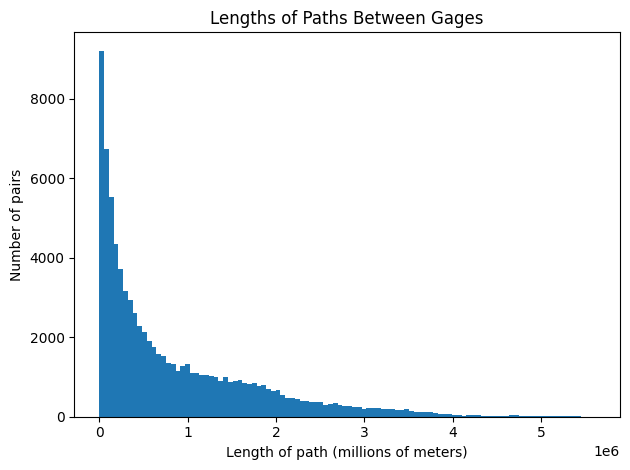

In [21]:
# Plot the length of the path between gages for each pair of gages
plt.hist(path_lengths, bins='auto')
plt.title('Lengths of Paths Between Gages')
plt.xlabel('Length of path (millions of meters)')
plt.ylabel('Number of pairs')
plt.tight_layout()
plt.savefig('gage_pair_graphs/path_lengths_histogram.png')

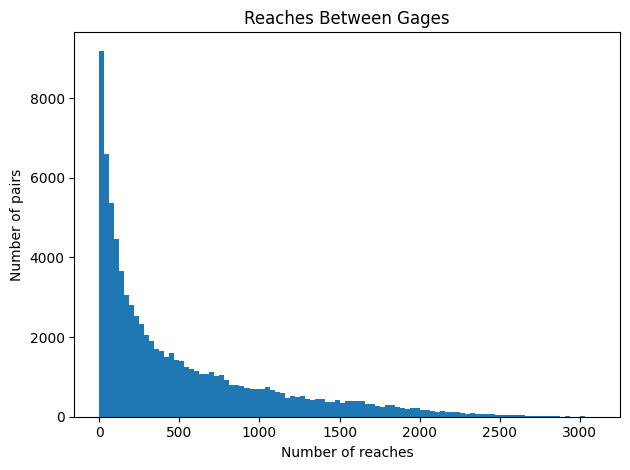

In [22]:
# Plot the number of reaches between gages for each pair of gages
plt.hist(reaches_between, bins='auto')
plt.title('Reaches Between Gages')
plt.xlabel('Number of reaches')
plt.ylabel('Number of pairs')
plt.tight_layout()
plt.savefig('gage_pair_graphs/reaches_between_histogram.png')

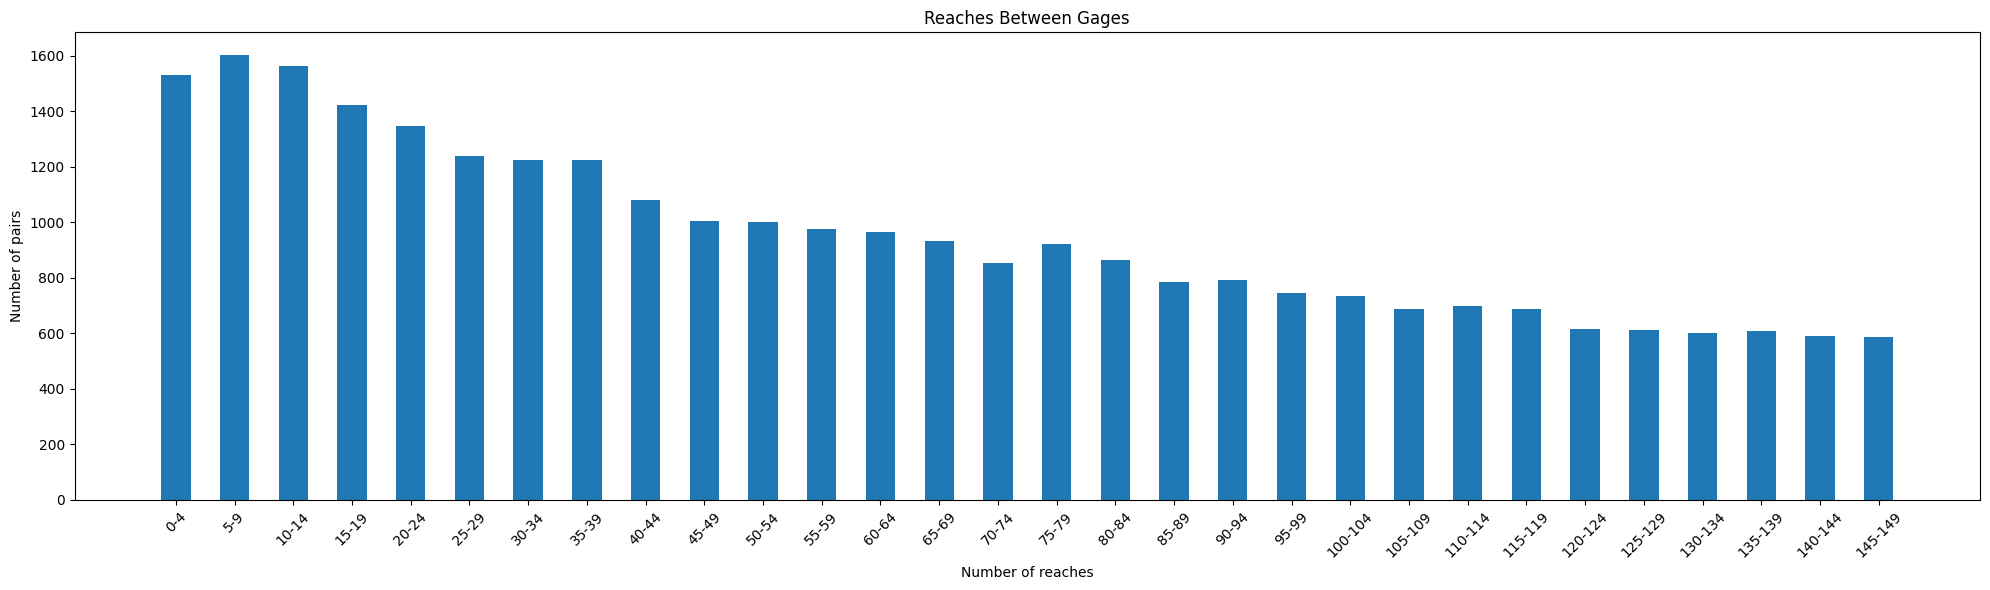

In [23]:
# Plot with individually labeled bins for pairs with 0 to 149 reaches between gages
reaches_between = np.array(reaches_between)
reaches_filtered = reaches_between[reaches_between < 150]

bins = np.arange(0, 150 + 5, 5) 

counts, _ = np.histogram(reaches_filtered, bins=bins)

labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]

x_pos = np.arange(len(counts))

bar_width = 0.5
plt.figure(figsize=(20, 6))

plt.bar(x_pos, counts, width=bar_width)

plt.xticks(x_pos, labels, rotation=45)

plt.title('Reaches Between Gages')
plt.xlabel('Number of reaches')
plt.ylabel('Number of pairs')

plt.tight_layout()
plt.savefig('gage_pair_graphs/labeled_bins_reaches_between_histogram.png')

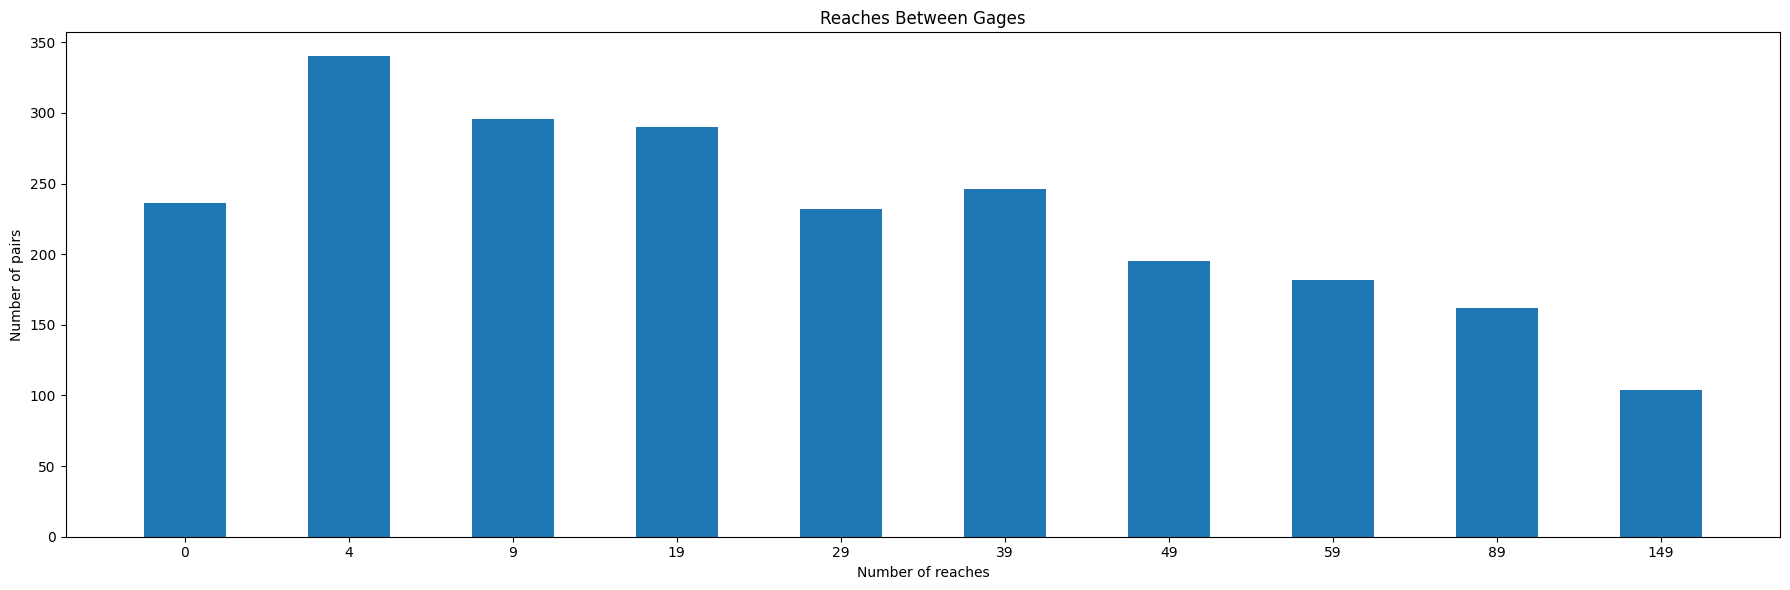

In [24]:
# Plot for the specific numbers of reaches the hydro transformer model was trained on
# Note: n1 for the ML model is equivalent to 0 reaches between gages, n2 is equivalent to 1, etc.
target_values = [0, 4, 9, 19, 29, 39, 49, 59, 89, 149]

occurences = {target: 0 for target in target_values}

targets_set = set(target_values)
for i in reaches_between:
    if i in targets_set:
        occurences[i] += 1

x_labels = [str(k) for k in target_values]
y_counts = list(occurences.values())
x_pos = np.arange(len(x_labels))

bar_width = 0.5

plt.figure(figsize=(18, 6))
plt.bar(x_pos, y_counts, width=bar_width)

plt.xticks(x_pos, x_labels, rotation=0)

plt.title('Reaches Between Gages')
plt.xlabel('Number of reaches')
plt.ylabel('Number of pairs')

plt.tight_layout()
plt.savefig('gage_pair_graphs/ml_training_reaches_between_bar_graph.png')